### Example 2: square-shape object

A square-shape object object is illuminated by a 30-degree plane wave $Ae^{i\vec{k}\cdot\vec{r}}$. The scattered field is modelled using the Helmholtz equation. The Ren-Liu hybrid absorbing boundary condition (HABC) is used to truncate the computational domain and the number of absorbing layers is $N = 10$. The size of the interior domain $\Omega_{\text{i}}$ is $[-6.0, 6.0] \times [-6.0, 6.0]$ $\text{mm}^2$, and the grid size is uniform in both the x- and y-directions, and is set to $h = 0.2$ mm

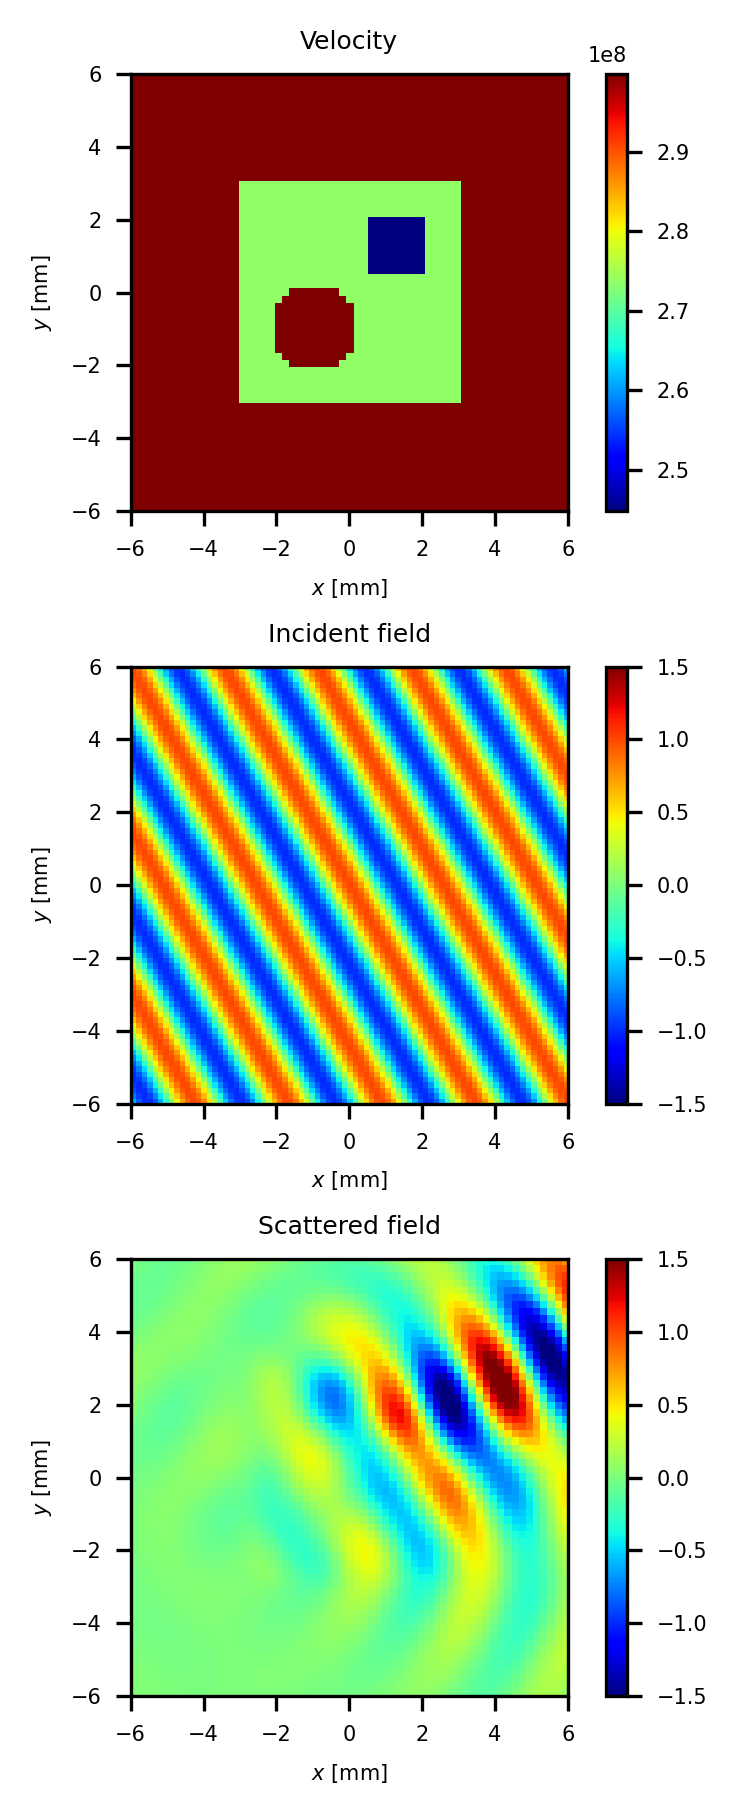

In [ ]:
from matplotlib.pyplot import *
import pyhelmholtz as ph

# Available source: PointSource, PlaneWave
# Available ABM: EM1, EM2, HEM1, HEM2, PML, PMLEM1, PMLEM2

limits = (-0.006, 0.006, -0.006, 0.006)
domain = ph.Domain(limits=limits, h=0.0002)
c0 = ph.LIGHT_SPEED
c1, c2 = c0/1.2**.5, c0/1.5**.5
bb1 = -0.003, 0.003, -0.003, 0.003    
bb2 = 0.0006, 0.002, 0.0006, 0.002
domain.add_rectangle(bb1, c1)
domain.add_rectangle(bb2, c2)
domain.add_circle((-.001,-.001), .0012, c0)

source = ph.PlaneWave(freq=1e+11, theta=30)
hs = ph.HelmholtzSolver(domain=domain, source=source, abm=ph.PML(n=10))
hs.solve()
rcParams['font.size'] = 5
figure(figsize=(2.7,6),dpi=300)
subplot(311);hs.viz(data="velocity", unit="mm")
subplot(312);hs.viz(data="incident", unit="mm", vlim=[-1.5,1.5])
subplot(313);hs.viz(data="solution", unit="mm", vlim=[-1.5,1.5])
gcf().tight_layout()